In [ ]:
# OpenHousing - House Price Prediction PoC

## Objective

Build a machine learning regression model to predict real estate prices using socio-economic indicators.

## Dataset

Boston Housing Dataset

Source:
https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv

## Machine Learning Task

Problem Type:
Supervised Learning

Task:
Regression

Target Variable:
MEDV (Median house value)


SyntaxError: invalid syntax (1726932107.py, line 5)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")


In [ ]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

df.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.shape


(506, 14)

In [ ]:
df.columns


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [ ]:
df.info()


In [ ]:
df.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['medv'],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("MEDV (Thousands of USD)")
plt.ylabel("Frequency")

plt.show()


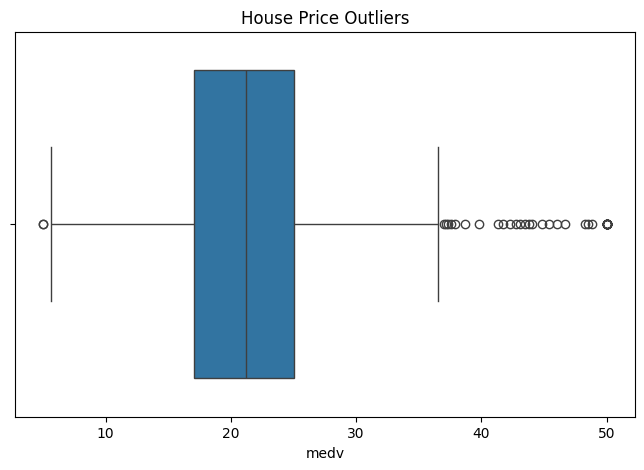

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['medv']
)

plt.title("House Price Outliers")

plt.show()


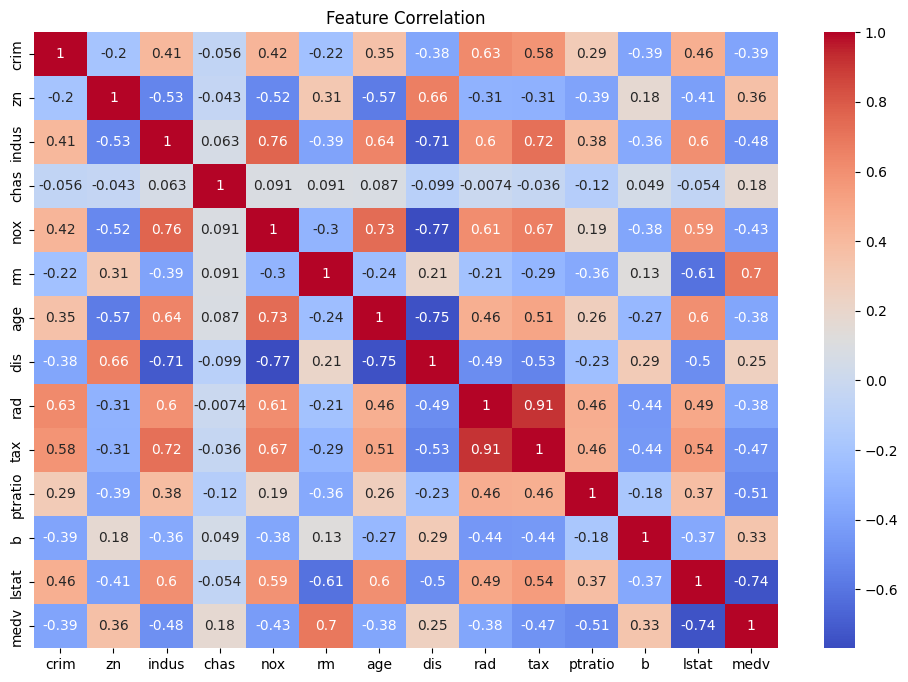

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()


In [ ]:
corr['medv'].sort_values(ascending=False)


,medv
medv,1.000000
rm,0.695360
zn,0.360445
b,0.333461
dis,0.249929
chas,0.175260
age,-0.376955
rad,-0.381626
crim,-0.388305
nox,-0.427321


In [ ]:
X = df.drop("medv", axis=1)
y = df["medv"]

print(X.shape)
print(y.shape)


(506, 13)
(506,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (404, 13)
Testing data : (102, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 3.189091965887848
RMSE: 4.928602182665336
R²  : 0.668759493535632


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, dt_pred)
rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Decision Tree Results
MAE : 2.394117647058824
RMSE: 3.2273949915330395
R²  : 0.8579634380978161


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Random Forest Results
MAE : 2.0413137254901943
RMSE: 2.917224938728114
R²  : 0.8839525117021145


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
2,Random Forest,2.041314,2.917225,0.883953
1,Decision Tree,2.394118,3.227395,0.857963
0,Linear Regression,3.189092,4.928602,0.668759
